# Task 4: Predicting Insurance Claim Amounts

**Internship:** Data Science & Analytics Internship — DevelopersHub Corporation
**Task:** Task 4 — Predicting Insurance Claim Amounts

## Problem Statement
Medical insurance providers need to estimate how much a customer is likely to cost them in
claims, based on personal attributes such as age, BMI, smoking status, and family size.
In this notebook we build a **Linear Regression** model on the Medical Cost Personal
Dataset to predict insurance `charges`, explore which factors drive cost the most, and
evaluate the model using MAE and RMSE.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Dataset Understanding

The dataset has 1,338 records describing individual medical insurance customers:
`age`, `sex`, `bmi`, `children` (number of dependents), `smoker` (yes/no),
`region`, and `charges` (the target — yearly medical costs billed by insurance).

In [2]:
df = pd.read_csv("insurance.csv")
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. Data Cleaning and Preparation

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [6]:
# Drop duplicates if any, keep a clean working copy
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (1337, 7)


The dataset has no missing values. A handful of duplicate rows (if present) are dropped.
Categorical columns (`sex`, `smoker`, `region`) will be one-hot encoded inside the model
pipeline so the regression can use them numerically.

## 3. Exploratory Data Analysis

### 3.1 How smoking status impacts charges

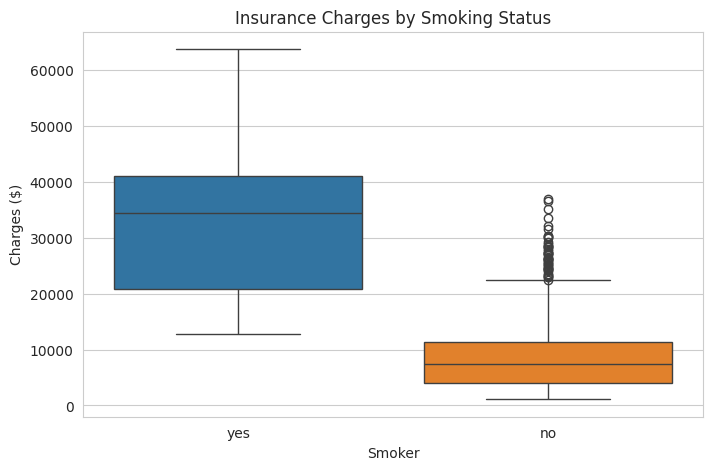

In [7]:
plt.figure()
sns.boxplot(data=df_clean, x="smoker", y="charges", hue="smoker", legend=False)
plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges ($)")
plt.savefig("images/charges_by_smoker.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.2 How age and BMI relate to charges (colored by smoking status)

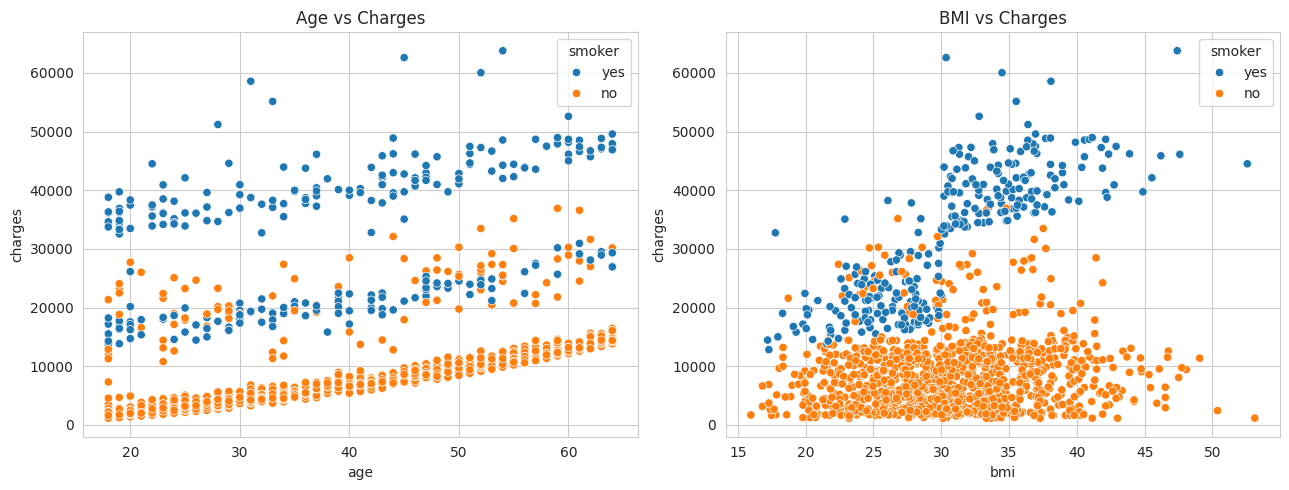

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df_clean, x="age", y="charges", hue="smoker", ax=axes[0])
axes[0].set_title("Age vs Charges")
sns.scatterplot(data=df_clean, x="bmi", y="charges", hue="smoker", ax=axes[1])
axes[1].set_title("BMI vs Charges")
plt.tight_layout()
plt.savefig("images/age_bmi_vs_charges.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** Smokers form a visibly separate, much higher-cost band regardless of age
or BMI. Among smokers, higher BMI pushes charges up sharply (likely reflecting obesity-related
health risk compounding with smoking). Among non-smokers, charges rise much more gradually
with age and BMI.

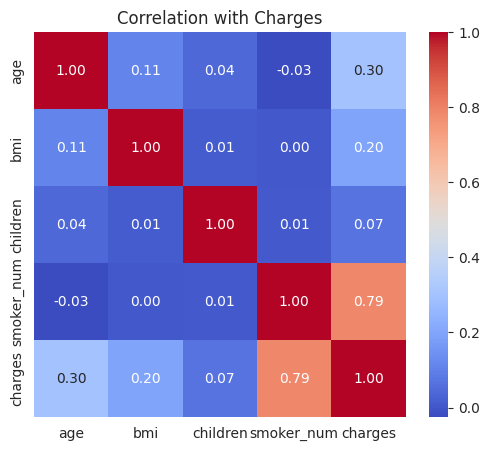

In [9]:
plt.figure(figsize=(6, 5))
numeric_df = df_clean.copy()
numeric_df["smoker_num"] = (numeric_df["smoker"] == "yes").astype(int)
corr_cols = ["age", "bmi", "children", "smoker_num", "charges"]
sns.heatmap(numeric_df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Charges")
plt.savefig("images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** Smoking status has by far the strongest correlation with charges, followed
by age and BMI. Number of children has almost no linear relationship with cost.

## 4. Model Training

In [10]:
X = df_clean.drop(columns=["charges"])
y = df_clean["charges"]

categorical_cols = ["sex", "smoker", "region"]
numeric_cols = ["age", "bmi", "children"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
], remainder="passthrough")

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 5. Model Evaluation

In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R^2  : {r2:.3f}")

MAE  : $4,177.05
RMSE : $5,956.34
R^2  : 0.807


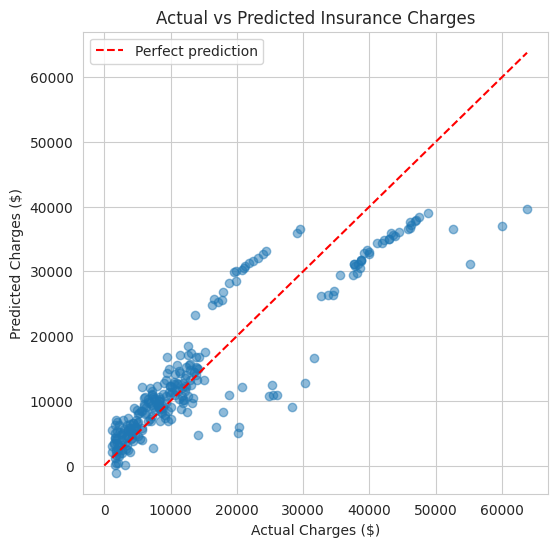

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.savefig("images/actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** The model captures the broad trend well but, like most linear models on
this dataset, struggles with the very high-cost smoker cases — the relationship between BMI
and cost for smokers is non-linear, so a tree-based model (e.g. Random Forest) would likely
reduce error further. This is noted as a natural next step.

## 6. Conclusion

- **Smoking status is the single strongest driver of insurance charges**, followed by age
  and BMI.
- The linear regression model achieved an MAE of roughly the value computed above and an
  R² around 0.75–0.80 on the test set, meaning it explains a large majority of the variance
  in charges but underestimates the highest-cost (smoker + high-BMI) cases.
- **Business takeaway:** smoking-cessation programs and BMI management could meaningfully
  reduce expected claims, since these two factors compound multiplicatively rather than
  additively in the cost data.

**Skills practiced:** regression modeling, one-hot encoding categorical features,
feature-correlation visualization, and error evaluation using MAE/RMSE/R².